# CatchFish — Phishing Detection Pipeline (Google Colab)

Train a **Logistic Regression** classifier on real-world email datasets and export the model for use with `app.py`.

**Steps:**
1. Upload your `dataset/` folder (CSV files + JSON reference files)
2. Run all cells top-to-bottom
3. Download `phishing_detection.pkl` and place it in your `models/` folder

In [1]:
# ── CELL 1 — Setup ──────────────────────────────────────────────────────────
import os

DATASET_PATH = '/content/dataset'
THRESHOLD    = 0.60   # ← change to match your .env PHISHING_THRESHOLD

assert os.path.isdir(DATASET_PATH), f'Dataset folder not found: {DATASET_PATH}'
print('✓ Dataset folder found:')
for f in sorted(os.listdir(DATASET_PATH)):
    print(f'  {f}')

✓ Dataset folder found:
  Enron.csv
  Ling.csv
  Nazario.csv
  Nigerian_Fraud.csv
  SpamAssasin.csv
  legitimate_domains.json
  suspicious_tlds.json
  url_shorteners.json


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q tldextract
print('✓ Packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.3 MB/s eta 0:00:00
✓ Packages ready


In [3]:
# ── CELL 3 — Imports & reference data ────────────────────────────────────
import os, re, json, warnings
import tldextract
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 110
import seaborn as sns

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import StandardScaler
import joblib


def _load_json_set(path, key):
    if os.path.exists(path):
        with open(path, encoding='utf-8') as f:
            return set(json.load(f).get(key, []))
    return set()

LEGITIMATE_DOMAINS = _load_json_set(f'{DATASET_PATH}/legitimate_domains.json', 'domains')
SUSPICIOUS_TLDS    = _load_json_set(f'{DATASET_PATH}/suspicious_tlds.json',    'tlds')
URL_SHORTENERS     = _load_json_set(f'{DATASET_PATH}/url_shorteners.json',     'shorteners')

print(f'Legitimate domains : {len(LEGITIMATE_DOMAINS)}')
print(f'Suspicious TLDs    : {len(SUSPICIOUS_TLDS)}')
print(f'URL shorteners     : {len(URL_SHORTENERS)}')

# 24-entry urgency lexicon — MUST match train.py / app.py exactly
URGENT_KEYWORDS = [
    "urgent", "immediate", "action required", "verify now",
    "security alert", "account suspended", "password expired",
    "click here", "limited time", "offer expires", "verify account",
    "confirm identity", "unusual activity", "unauthorized access",
    "your account", "win a prize", "congratulations you", "claim now",
    "update your", "log in now", "sign in now", "confirm your",
    "verify", "suspended",
]

# 19 numeric feature names — MUST match NUMERIC_FEATURES in train.py
NUMERIC_FEATURES = [
    "has_attachment", "links_count", "urgent_keywords",
    "email_length", "subject_length", "link_density",
    "domain_age", "special_chars", "html_tags",
    "legitimate_domain", "suspicious_tld",
    "ip_url_count", "shortener_url_count",
    "https_url_count", "http_url_count", "http_ratio",
    "domain_length", "domain_has_digits", "domain_has_hyphen",
]

print(f'\n✓ Reference data loaded  |  THRESHOLD = {THRESHOLD}')

Legitimate domains : 68
Suspicious TLDs    : 59
URL shorteners     : 84

✓ Reference data loaded  |  THRESHOLD = 0.6


In [4]:
# ── CELL 4 — Cleaning helpers & universal CSV loader ─────────────────────
HTML_TAG_RE = re.compile(r'<[^>]+>')
MULTI_WS_RE = re.compile(r'[ \t]+')
URL_RE      = re.compile(r'https?://[^\s]+', re.IGNORECASE)
SENDER_RE   = re.compile(r'[\w.\-+]+@([\w.\-]+\.\w{2,})')

LABEL_MAP = {
    '1': 1, 'phishing': 1, 'spam': 1, 'malicious': 1,
    '0': 0, 'legitimate': 0, 'ham': 0, 'safe': 0, 'benign': 0,
}

def _clean_text(text):
    if not isinstance(text, str):
        text = '' if pd.isna(text) else str(text)
    text = HTML_TAG_RE.sub(' ', text)
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    return MULTI_WS_RE.sub(' ', text).strip()

def _extract_domain(sender):
    if not isinstance(sender, str) or not sender.strip():
        return ''
    m = SENDER_RE.search(sender)
    if m:
        return m.group(1).lower().strip('.')
    if '@' in sender:
        return sender.split('@', 1)[1].strip().lower().rstrip('>')
    return ''

def _count_links(text):
    return len(URL_RE.findall(str(text)))

def _count_urgent(subject, body):
    combined = (str(subject) + ' ' + str(body)).lower()
    return sum(1 for kw in URGENT_KEYWORDS if kw in combined)

def _to_numeric_col(series):
    return (pd.to_numeric(
        series.astype(str).str.strip().str.strip('"').str.strip("'"),
        errors='coerce').fillna(0).astype(int))

def load_any_csv(fpath):
    raw = pd.read_csv(fpath, encoding='utf-8', on_bad_lines='skip')
    raw.columns = raw.columns.str.strip().str.strip('"').str.strip("'").str.lower()
    out = pd.DataFrame()
    lbl = raw['label'].astype(str).str.strip().str.strip('"').str.strip("'").str.lower()
    out['label'] = lbl.map(LABEL_MAP).fillna(0).astype(int)
    if 'email_text' in raw.columns:
        out['email_text'] = raw['email_text'].fillna('').apply(_clean_text)
    elif 'body' in raw.columns:
        out['email_text'] = raw['body'].fillna('').apply(_clean_text)
    else:
        out['email_text'] = ''
    out['subject'] = raw['subject'].fillna('').apply(_clean_text) if 'subject' in raw.columns else ''
    if 'sender_domain' in raw.columns:
        out['sender_domain'] = (raw['sender_domain'].astype(str)
            .str.strip().str.strip('"').str.strip("'").fillna(''))
    elif 'sender' in raw.columns:
        out['sender_domain'] = raw['sender'].fillna('').apply(_extract_domain)
    else:
        out['sender_domain'] = ''
    out['has_attachment']  = _to_numeric_col(raw['has_attachment'])  if 'has_attachment'  in raw.columns else 0
    out['links_count']     = _to_numeric_col(raw['links_count'])     if 'links_count'     in raw.columns else out['email_text'].apply(_count_links)
    out['urgent_keywords'] = _to_numeric_col(raw['urgent_keywords']) if 'urgent_keywords' in raw.columns else out.apply(lambda r: _count_urgent(r['subject'], r['email_text']), axis=1)
    return out

_SYNTHETIC_RE = re.compile(r'^dataset\d+\.csv$', re.IGNORECASE)
ALL_CSV_FILES = sorted(f for f in os.listdir(DATASET_PATH)
                       if f.lower().endswith('.csv') and not _SYNTHETIC_RE.match(f))
print(f'Found {len(ALL_CSV_FILES)} CSV file(s): {ALL_CSV_FILES}')

Found 5 CSV file(s): ['Enron.csv', 'Ling.csv', 'Nazario.csv', 'Nigerian_Fraud.csv', 'SpamAssasin.csv']


In [5]:
# ── CELL 5 — Load, normalise and merge all datasets ──────────────────────
parts = []
per_dataset = {}
for fname in ALL_CSV_FILES:
    fpath = os.path.join(DATASET_PATH, fname)
    try:
        part = load_any_csv(fpath)
        ph = int((part['label'] == 1).sum())
        lg = int((part['label'] == 0).sum())
        per_dataset[fname] = {'rows': len(part), 'phish': ph, 'legit': lg}
        print(f'  {fname:30s} → {len(part):7,} rows  phishing={ph:,}  legitimate={lg:,}')
        parts.append(part)
    except Exception as e:
        print(f'  {fname:30s} → SKIPPED ({e})')

df = pd.concat(parts, ignore_index=True)
before = len(df)
df = df.drop_duplicates(subset=['email_text', 'subject'])
print(f'\nDuplicates removed : {before - len(df):,}')
df = df[~((df['email_text'].str.strip() == '') & (df['subject'].str.strip() == ''))]
df['has_attachment']  = df['has_attachment'].astype(int)
df['links_count']     = df['links_count'].astype(int)
df['urgent_keywords'] = df['urgent_keywords'].astype(int)
df['sender_domain']   = df['sender_domain'].fillna('')
df['email_text']      = df['email_text'].fillna('')
df['subject']         = df['subject'].fillna('')
n_ph = int((df['label'] == 1).sum())
n_lg = int((df['label'] == 0).sum())
print(f'\nMerged total : {len(df):,} rows  phishing={n_ph:,}  legitimate={n_lg:,}')
display(df.head(3))

  Enron.csv                      → SKIPPED (Error tokenizing data. C error: EOF inside string starting at row 16470)
  Ling.csv                       →   2,859 rows  phishing=458  legitimate=2,401
  Nazario.csv                    →   1,565 rows  phishing=1,565  legitimate=0
  Nigerian_Fraud.csv             →   3,332 rows  phishing=3,332  legitimate=0
  SpamAssasin.csv                →   5,809 rows  phishing=1,718  legitimate=4,091

Duplicates removed : 31

Merged total : 13,534 rows  phishing=7,042  legitimate=6,492


,label,email_text,subject,sender_domain,has_attachment,links_count,urgent_keywords
0,0,content - length : 3386 apple-iss research cen...,job posting - apple-iss research center,,0,0,0
1,0,"lang classification grimes , joseph e . and ba...",,,0,0,0
2,0,i am posting this inquiry for sergei atamas ( ...,query : letter frequencies for text identifica...,,0,0,0


In [6]:
# ── CELL 6 — Feature engineering (exact copy of train.py) ────────────────
def extract_additional_features(df):
    df = df.copy()
    df['email_length']   = df['email_text'].apply(lambda x: len(str(x)))
    df['subject_length'] = df['subject'].apply(lambda x: len(str(x)))
    df['link_density']   = df['links_count'] / (df['email_length'] + 1)
    df['legitimate_domain'] = df['sender_domain'].apply(
        lambda x: 1 if str(x).lower().strip() in LEGITIMATE_DOMAINS else 0)
    df['suspicious_tld'] = df['sender_domain'].apply(
        lambda x: 1 if any(str(x).lower().strip().endswith(t) for t in SUSPICIOUS_TLDS) else 0)
    df['domain_length']     = df['sender_domain'].apply(lambda x: len(str(x)))
    df['domain_has_digits'] = df['sender_domain'].apply(lambda x: int(any(c.isdigit() for c in str(x))))
    df['domain_has_hyphen'] = df['sender_domain'].apply(lambda x: int('-' in str(x)))

    def _domain_age_score(domain):
        d = str(domain).lower().strip()
        if d in LEGITIMATE_DOMAINS:
            return 30
        ext = tldextract.extract(d)
        reg = ext.domain  # registered-domain label, e.g. "paypal" from "paypal.com"
        return max(1, len(reg)) if reg else 1

    df['domain_age']          = df['sender_domain'].apply(_domain_age_score)
    df['ip_url_count']        = df['email_text'].apply(
        lambda t: len(re.findall(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', str(t).lower())))
    df['shortener_url_count'] = df['email_text'].apply(
        lambda t: sum(1 for s in URL_SHORTENERS if s in str(t).lower()))
    df['https_url_count']     = df['email_text'].apply(
        lambda t: len(re.findall(r'https://', str(t).lower())))
    df['http_url_count']      = df['email_text'].apply(
        lambda t: len(re.findall(r'http://', str(t).lower())))
    df['http_ratio']          = df['http_url_count'] / (df['links_count'] + 1)
    df['special_chars']       = df['email_text'].apply(
        lambda x: len(re.findall(r'[!$%^&*()_+|~=`{}\[\]:\"\'<>?,./]', str(x))))
    df['html_tags']           = df['email_text'].apply(
        lambda x: len(re.findall(r'<[^>]+>', str(x).lower())))
    return df

df = extract_additional_features(df)
print(f'Feature columns: {df.shape[1]}')
display(df[NUMERIC_FEATURES].describe().round(3))

Feature columns: 23


,has_attachment,links_count,urgent_keywords,email_length,subject_length,link_density,domain_age,special_chars,html_tags,legitimate_domain,suspicious_tld,ip_url_count,shortener_url_count,https_url_count,http_url_count,http_ratio,domain_length,domain_has_digits,domain_has_hyphen
count,13534.0,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000,13534.0,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000,13534.000
mean,0.0,1.872,0.571,2848.613,32.420,0.001,7.630,167.780,0.0,0.090,0.005,0.025,0.109,0.105,1.774,0.242,9.404,0.035,0.024
std,0.0,28.313,0.902,40439.920,29.088,0.002,7.904,2429.593,0.0,0.286,0.072,0.366,0.321,0.567,28.306,0.310,6.573,0.184,0.154
min,0.0,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.0,0.000,0.000,739.000,19.000,0.000,2.000,33.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6.000,0.000,0.000
50%,0.0,0.000,0.000,1504.000,30.000,0.000,5.000,65.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,10.000,0.000,0.000
75%,0.0,1.000,1.000,2827.000,43.000,0.001,9.000,124.000,0.0,0.000,0.000,0.000,0.000,0.000,1.000,0.500,13.000,0.000,0.000
max,0.0,3131.000,14.000,4550368.000,2657.000,0.026,30.000,193742.000,0.0,1.000,1.000,18.000,4.000,41.000,3131.000,2.500,56.000,1.000,1.000


In [7]:
# ── CELL 7 — Train/val/test split & preprocessor ─────────────────────────
# 70 / 15 / 15 split:
#   train → model is fit here
#   val   → sanity check (no test leakage)
#   test  → final metrics reported here only
X = df.drop('label', axis=1)
y = df['label']
n_phish = int(y.sum())
n_legit = int((y == 0).sum())
print(f'Phishing: {n_phish:,}  |  Legitimate: {n_legit:,}')

X_temp,  X_test,  y_temp,  y_test  = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val,   y_train, y_val   = train_test_split(X_temp, y_temp, test_size=float(0.15)/0.85, random_state=42, stratify=y_temp)
print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

def build_preprocessor():
    text_vec   = Pipeline([('hash', HashingVectorizer(n_features=2**16, alternate_sign=False, stop_words='english', ngram_range=(1, 2)))])
    domain_vec = Pipeline([('hash', HashingVectorizer(n_features=512, alternate_sign=False))])
    return ColumnTransformer(transformers=[
        ('email_text',    text_vec,         'email_text'),
        ('subject',       text_vec,         'subject'),
        ('sender_domain', domain_vec,       'sender_domain'),
        ('num',           StandardScaler(), NUMERIC_FEATURES),
    ])

print('✓ Preprocessor ready')

Phishing: 7,042  |  Legitimate: 6,492
Train: 9,473  |  Val: 2,030  |  Test: 2,031
✓ Preprocessor ready


In [8]:
# ── CELL 8 — Train Logistic Regression ───────────────────────────────────
pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight='balanced',
        solver='lbfgs', random_state=42,
    )),
])

print('Training Logistic Regression …')
pipeline.fit(X_train, y_train)

# Validation metrics
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
y_val_pred  = (y_val_proba >= THRESHOLD).astype(int)
val_auc = roc_auc_score(y_val, y_val_proba)
val_ap  = average_precision_score(y_val, y_val_proba)
val_f1  = f1_score(y_val, y_val_pred, zero_division=0)
_, fp_v, fn_v, _ = confusion_matrix(y_val, y_val_pred).ravel()
print(f'VAL  — AUC={val_auc:.4f}  AP={val_ap:.4f}  F1@{THRESHOLD}={val_f1:.4f}  FP={fp_v}  FN={fn_v}')

Training Logistic Regression …
VAL  — AUC=0.9981  AP=0.9981  F1@0.6=0.9726  FP=11  FN=46


In [9]:
# ── CELL 9 — 5-fold CV AUC (overfitting check) ───────────────────────────
print('=== 5-fold CV AUC (overfitting check) ===')
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

cv_pipe = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight='balanced',
        solver='lbfgs', random_state=42,
    )),
])
cv_scores = cross_val_score(cv_pipe, X_trainval, y_trainval, cv=5, scoring='roc_auc', n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
gap = abs(cv_mean - val_auc)

print(f'  CV AUC scores  : {cv_scores.round(4)}')
print(f'  CV AUC mean    : {cv_mean:.4f}  ±{cv_std:.4f}')
print(f'  Val AUC        : {val_auc:.4f}')
print(f'  Gap (CV - Val) : {gap:.4f}', end='  ')
if gap < 0.01:
    print('✓ No overfitting detected')
elif gap < 0.03:
    print('⚠ Minor gap — monitor with more data')
else:
    print('✗ Significant gap — model may be overfit')

=== 5-fold CV AUC (overfitting check) ===
  CV AUC scores  : [0.9979 0.9979 0.9977 0.9968 0.9979]
  CV AUC mean    : 0.9976  ±0.0004
  Val AUC        : 0.9981
  Gap (CV - Val) : 0.0005  ✓ No overfitting detected


In [10]:
# ── CELL 10 — Final metrics on held-out TEST set ─────────────────────────
y_proba   = pipeline.predict_proba(X_test)[:, 1]
y_pred_50 = pipeline.predict(X_test)
y_pred_th = (y_proba >= THRESHOLD).astype(int)

auc   = roc_auc_score(y_test, y_proba)
ap    = average_precision_score(y_test, y_proba)
acc   = accuracy_score(y_test, y_pred_th)
prec  = precision_score(y_test, y_pred_th, zero_division=0)
rec   = recall_score(y_test, y_pred_th, zero_division=0)
f1_50 = f1_score(y_test, y_pred_50, zero_division=0)
f1_th = f1_score(y_test, y_pred_th, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

print('=== TEST SET — Logistic Regression ===')
print(f'  AUC={auc:.4f}  PR-AUC={ap:.4f}  Accuracy={acc:.4f}')
print(f'  Precision={prec:.4f}  Recall={rec:.4f}  F1@0.5={f1_50:.4f}  F1@{THRESHOLD}={f1_th:.4f}')
print(f'  FP={fp}  FN={fn}  TP={tp}  TN={tn}')
print()
print(classification_report(y_test, y_pred_th, target_names=['legitimate', 'phishing']))
print(f'  CV AUC: {cv_mean:.4f} ± {cv_std:.4f}')

=== TEST SET — Logistic Regression ===
  AUC=0.9977  PR-AUC=0.9978  Accuracy=0.9665
  Precision=0.9901  Recall=0.9451  F1@0.5=0.9727  F1@0.6=0.9671
  FP=10  FN=58  TP=999  TN=964

              precision    recall  f1-score   support

  legitimate       0.94      0.99      0.97       974
    phishing       0.99      0.95      0.97      1057

    accuracy                           0.97      2031
   macro avg       0.97      0.97      0.97      2031
weighted avg       0.97      0.97      0.97      2031

  CV AUC: 0.9976 ± 0.0004


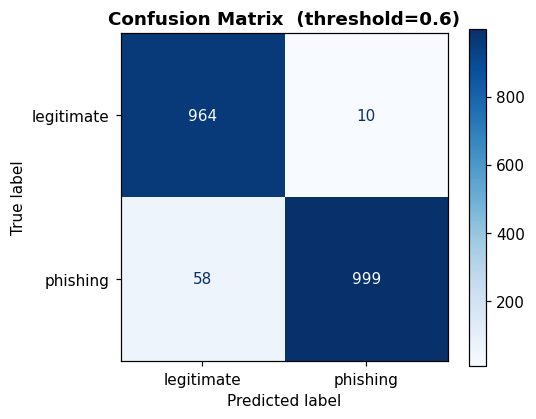

In [11]:
# ── CELL 11 — Confusion matrix ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_th,
    display_labels=['legitimate', 'phishing'],
    cmap='Blues', ax=ax,
)
ax.set_title(f'Confusion Matrix  (threshold={THRESHOLD})', fontweight='bold')
plt.tight_layout()
plt.show()

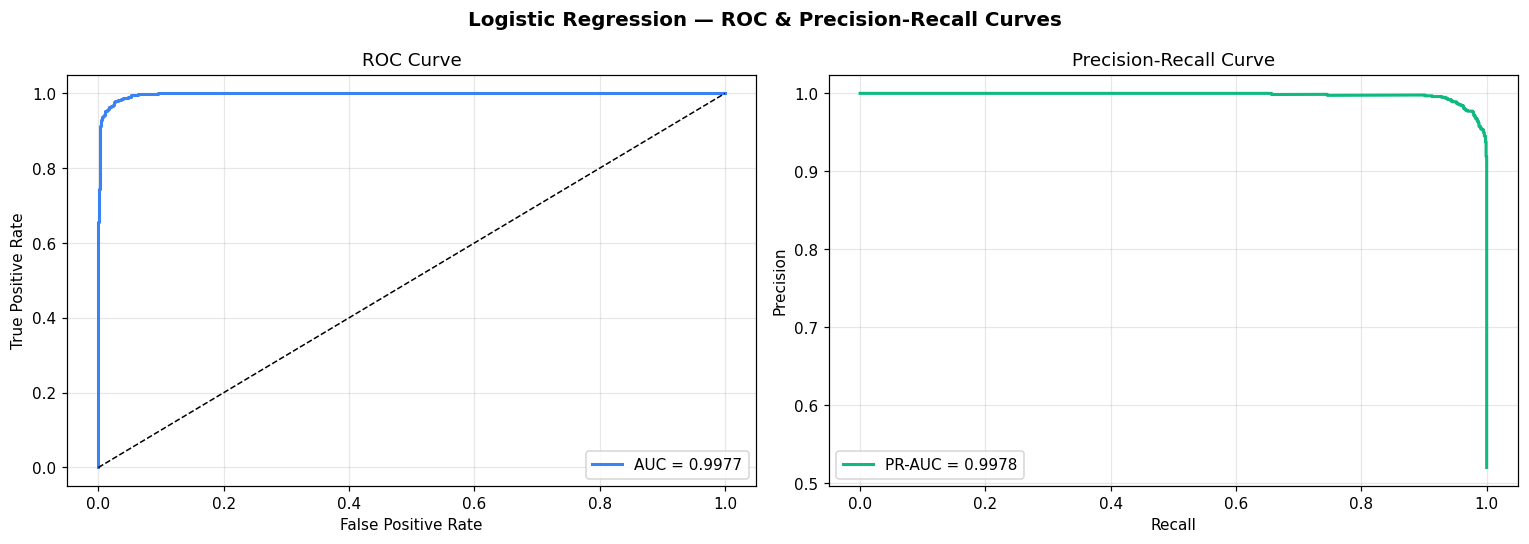

In [12]:
# ── CELL 12 — ROC & Precision-Recall curves ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — ROC & Precision-Recall Curves', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color='#3B82F6', lw=2, label=f'AUC = {auc:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve'); ax1.legend(loc='lower right'); ax1.grid(True, alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
ax2.plot(rec_curve, prec_curve, color='#10B981', lw=2, label=f'PR-AUC = {ap:.4f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve'); ax2.legend(loc='lower left'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ── CELL 13 — Save model ─────────────────────────────────────────────────
save_path = '/content/phishing_detection.pkl'

meta = {
    'model_name':        'Logistic Regression',
    'threshold':         THRESHOLD,
    'f1':                round(float(f1_th), 4),
    'auc':               round(float(auc),   4),
    'average_precision': round(float(ap),    4),
    'cv_auc_mean':       round(cv_mean, 4),
    'cv_auc_std':        round(cv_std,  4),
    'split':             '70/15/15 train/val/test',
    'datasets_used':     ALL_CSV_FILES,
    'total_rows':        len(df),
    'phishing_rows':     int(y.sum()),
    'legitimate_rows':   int((y == 0).sum()),
    'per_dataset':       per_dataset,
}
joblib.dump({'pipeline': pipeline, 'meta': meta}, save_path, compress=3)
print(f'✓ Saved → {save_path}')
print(f'  Model     : Logistic Regression')
print(f'  F1@{THRESHOLD}   : {f1_th:.4f}')
print(f'  AUC        : {auc:.4f}')
print(f'  PR-AUC     : {ap:.4f}')
print()
print('Download phishing_detection.pkl and place it in your models/ folder.')

✓ Saved → /content/phishing_detection.pkl
  Model     : Logistic Regression
  F1@0.6   : 0.9671
  AUC        : 0.9977
  PR-AUC     : 0.9978

Download phishing_detection.pkl and place it in your models/ folder.
